# PA-1: Algorithms for Data Science

Code for the four topics: JL Lemma, LSH, Randomized SVD, Spectral Clustering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## JL Lemma

### Question 1: Visualizing random projections

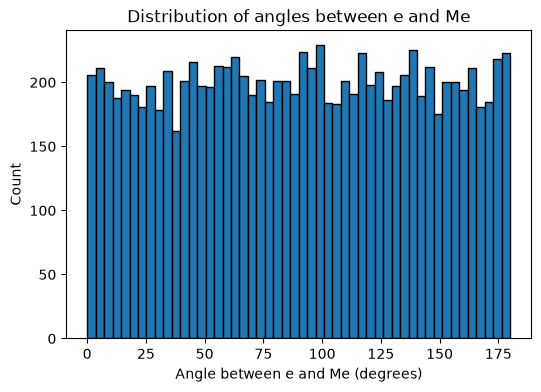

In [2]:
m = 10_000
e = np.array([1.0, 0.0])

M = rng.normal(size=(m, 2, 2))
Me = M @ e  # shape (m, 2), Me[i] = M_i @ e = first column of M_i

cos_theta = (Me @ e) / np.linalg.norm(Me, axis=1)
cos_theta = np.clip(cos_theta, -1.0, 1.0)
angles = np.degrees(np.arccos(cos_theta))

plt.figure(figsize=(6, 4))
plt.hist(angles, bins=50, edgecolor="black")
plt.xlabel("Angle between e and Me (degrees)")
plt.ylabel("Count")
plt.title("Distribution of angles between e and Me")
plt.show()

### Question 2: JL From Scratch

In [3]:
# DATA CELL
# DO NOT EDIT THIS CELL
def get_data(d, n):
    rng = np.random.default_rng(seed = 1234)
    X = rng.uniform(
        size=(d, n)
    )
    return X
d, n = 10_000, 5_000
X = get_data(d, n)

In [4]:
# JL bound: smallest k for which a random projection preserves all
# pairwise distances within (1 +/- eps), w.h.p.
eps = 0.2

k = int(np.ceil(4 * np.log(n) / (eps**2 / 2 - eps**3 / 3)))
print(f"n = {n}, eps = {eps}, d = {d}")
print(f"Required k (JL bound): {k}")

n = 5000, eps = 0.2, d = 10000
Required k (JL bound): 1966


In [5]:
def pairwise_sq_dists(Y):
    """Y has shape (features, n_points). Returns the (n_points, n_points)
    matrix of squared Euclidean distances between columns of Y, computed via
    the Gram-matrix identity ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a.b (fast,
    uses a single big matmul instead of looping over pairs)."""
    G = Y.T @ Y
    sq_norms = np.diag(G)
    D2 = sq_norms[:, None] + sq_norms[None, :] - 2 * G
    return np.maximum(D2, 0.0)  # clip tiny negative values from fp error


def random_projection_matrix(k, d, rng):
    """k x d Gaussian random matrix, scaled by 1/sqrt(k) so that
    E[||Rx||^2] = ||x||^2, i.e. it preserves squared length in expectation."""
    return rng.normal(size=(k, d)) / np.sqrt(k)

In [6]:
# Precompute the original pairwise squared distances once (doesn't depend
# on the random matrix), and reuse it for every trial.
low, high = 1 - eps, 1 + eps
iu = np.triu_indices(n, k=1)  # indices of all pairs (i, j), i < j

D2_orig_pairs = pairwise_sq_dists(X)[iu]

max_trials = 10
n_matrices_tried = 0
f = None  # will hold the projection matrix once one passes the check
ratio = None

for trial in range(1, max_trials + 1):
    n_matrices_tried = trial
    R = random_projection_matrix(k, d, rng)
    Y = R @ X  # projected dataset, shape (k, n)

    D2_proj_pairs = pairwise_sq_dists(Y)[iu]
    ratio = D2_proj_pairs / D2_orig_pairs

    if np.all((ratio >= low) & (ratio <= high)):
        f = R
        break

print(f"Found a valid {eps}-isometry: {f is not None}")
print(f"Number of random matrices generated: {n_matrices_tried}")
print(f"Ratio ||f(x)-f(y)||^2 / ||x-y||^2 range: "
      f"[{ratio.min():.4f}, {ratio.max():.4f}]  (need to lie in [{low}, {high}])")

Found a valid 0.2-isometry: True
Number of random matrices generated: 1
Ratio ||f(x)-f(y)||^2 / ||x-y||^2 range: [0.8475, 1.1807]  (need to lie in [0.8, 1.2])


### Question 3: Effect of k on pair-wise distances

In [7]:
# DATA CELL
# DO NOT EDIT THIS CELL
def get_sparse_data(d, n):
    rng = np.random.default_rng(seed = 1234)
    return rng.choice(
        [0, 1],
        p=[0.8, 0.2],
        size=(d, n)
    )
d, n = 2_000, 1000
X = get_sparse_data(d, n)

In [8]:
# All C(n, 2) pairs of original squared distances, computed once and reused
# for every k below (X doesn't depend on k).
iu3 = np.triu_indices(n, k=1)
D2_orig_pairs_3 = pairwise_sq_dists(X)[iu3]

k_values = [100, 500, 1500]
projected_sq_dists = {}

for k_val in k_values:
    R = random_projection_matrix(k_val, d, rng)
    Y = R @ X  # shape (k_val, n)
    projected_sq_dists[k_val] = pairwise_sq_dists(Y)[iu3]

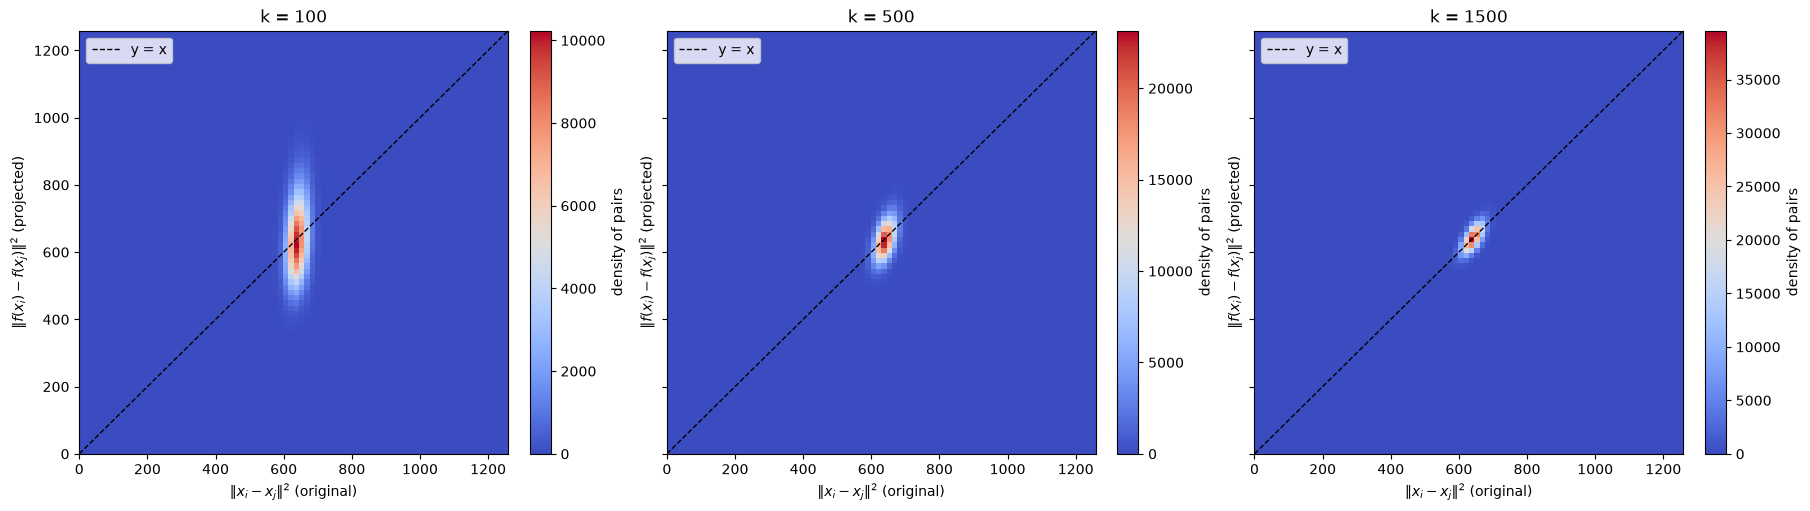

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True, sharex=True, sharey=True)

# Common axis range across all three panels, so the panels are directly
# comparable (otherwise matplotlib autoscales each one differently).
global_max = max(
    D2_orig_pairs_3.max(),
    max(d2.max() for d2 in projected_sq_dists.values()),
)
lims = [0, global_max]

for ax, k_val in zip(axes, k_values):
    d2_proj = projected_sq_dists[k_val]

    h = ax.hist2d(
        D2_orig_pairs_3, d2_proj,
        bins=80, range=[lims, lims], cmap="coolwarm",
    )
    fig.colorbar(h[3], ax=ax, label="density of pairs")

    ax.plot(lims, lims, "k--", linewidth=1, label="y = x")

    ax.set_xlabel(r"$\|x_i - x_j\|^2$ (original)")
    ax.set_ylabel(r"$\|f(x_i) - f(x_j)\|^2$ (projected)")
    ax.set_title(f"k = {k_val}")
    ax.legend(loc="upper left")

plt.show()

### Question 4: Linear Separability

In [10]:
# DATA CELL
# DO NOT EDIT THIS CELL
rng = np.random.default_rng(seed=1035)
d = 2_000
n = 1_000

w = rng.uniform(-2, 2, d)
X = rng.normal(size=(n, d))
y = np.where(X @ w >= 0, 1, 0)

In [11]:
from sklearn.linear_model import Perceptron

# Verify: fit a perceptron on the original (un-projected) data.
clf = Perceptron()
clf.fit(X, y)
train_acc = clf.score(X, y)
print(f"Perceptron training accuracy on original data (d={d}): {train_acc:.4f}")

Perceptron training accuracy on original data (d=2000): 1.0000


In [12]:
def run_experiment(k, X, y, rng):
    """One experiment: build a JL random projection to R^k, project X,
    fit a perceptron on the projected data, and return its accuracy."""
    n_samples, d_features = X.shape
    R = random_projection_matrix(k, d_features, rng)  # (k, d)
    X_proj = X @ R.T                                  # (n, k)

    clf = Perceptron()
    clf.fit(X_proj, y)
    return clf.score(X_proj, y)

In [13]:
# Cluster: for each k in {100, 150, ..., 1000}, run the experiment 50 times
# (fresh random projection matrix each time) and average the accuracies.
k_values_4 = list(range(100, 1001, 50))
n_runs = 50

rng_exp = np.random.default_rng(2024)

acc_matrix = np.zeros((len(k_values_4), n_runs))
for i, k_val in enumerate(k_values_4):
    for run in range(n_runs):
        acc_matrix[i, run] = run_experiment(k_val, X, y, rng_exp)

mean_acc = acc_matrix.mean(axis=1)

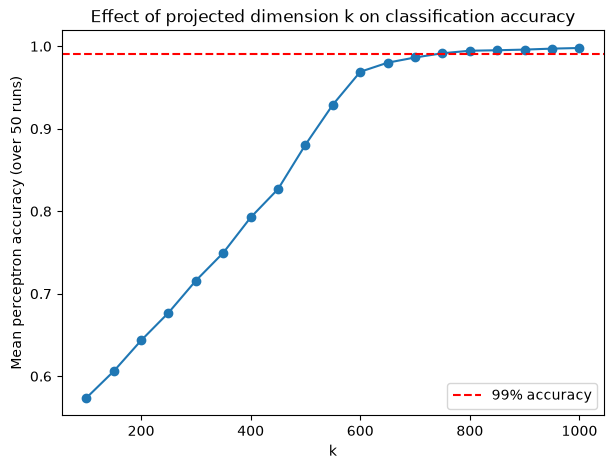

Smallest k with mean accuracy >= 99%: k = 750 (accuracy = 0.9915)


In [14]:
# Plot: accuracy vs k, and find the smallest k reaching 99% accuracy.
plt.figure(figsize=(7, 5))
plt.plot(k_values_4, mean_acc, marker="o")
plt.axhline(0.99, color="red", linestyle="--", label="99% accuracy")
plt.xlabel("k")
plt.ylabel("Mean perceptron accuracy (over 50 runs)")
plt.title("Effect of projected dimension k on classification accuracy")
plt.legend()
plt.show()

above_99 = np.where(mean_acc >= 0.99)[0]
if len(above_99) > 0:
    k_min = k_values_4[above_99[0]]
    print(f"Smallest k with mean accuracy >= 99%: k = {k_min} "
          f"(accuracy = {mean_acc[above_99[0]]:.4f})")
else:
    print("No k in the tested range reached 99% mean accuracy.")
    print(f"Best: k = {k_values_4[np.argmax(mean_acc)]}, "
          f"accuracy = {mean_acc.max():.4f}")

## LSH

### Question 1: Understanding the Datar-hash function

In [15]:
def collision_prob_curve(t_values, d, w, rng, n_trials=20_000, x=None, direction=None):
    """Estimate P(h_ab(x) = h_ab(y)) for a Datar-hash function, for each
    distance t in t_values, with points in R^d and bucket width w.

    x is a fixed anchor point (default: origin) and `direction` is the
    (unit) direction from x to y (default: a random direction, drawn once
    and reused for every t, so we're tracing one pair of points as they are
    pulled apart along a fixed line). Only ||x - y|| = t matters for the
    theory -- so any anchor/direction works.

    Each entry is a Monte Carlo estimate: for that t, we draw n_trials
    independent (a, b) pairs and take the fraction that collide -- i.e.
    each point on the curve already *is* an average over many trials.
    """
    if x is None:
        x = np.zeros(d)
    if direction is None:
        direction = rng.normal(size=d)
        direction /= np.linalg.norm(direction)

    probs = np.empty(len(t_values))
    for i, t in enumerate(t_values):
        y = x + t * direction
        a = rng.normal(size=(n_trials, d))       # a ~ N(0, I_d), one per trial
        b = rng.uniform(0, w, size=n_trials)      # b ~ U[0, w], one per trial
        hx = np.floor((x @ a.T + b) / w)
        hy = np.floor((y @ a.T + b) / w)
        probs[i] = np.mean(hx == hy)
    return probs


def collision_prob_theory(t, w):
    """Closed-form P(collision) for distance t and bucket width w, derived
    from p(t) = E_D[max(0, 1 - |D|/w)] with D = a^T(x-y) ~ N(0, t^2):

        p(t) = 2*Phi(w/t) - 1 - (2 / (w/t * sqrt(2*pi))) * (1 - exp(-(w/t)^2 / 2))
    """
    from scipy.stats import norm
    t = np.asarray(t, dtype=float)
    c = w / t
    return 2 * norm.cdf(c) - 1 - (2 / (c * np.sqrt(2 * np.pi))) * (1 - np.exp(-c**2 / 2))

**(1) Collision probability vs. ||x - y||**, for d = 2, w = 1.

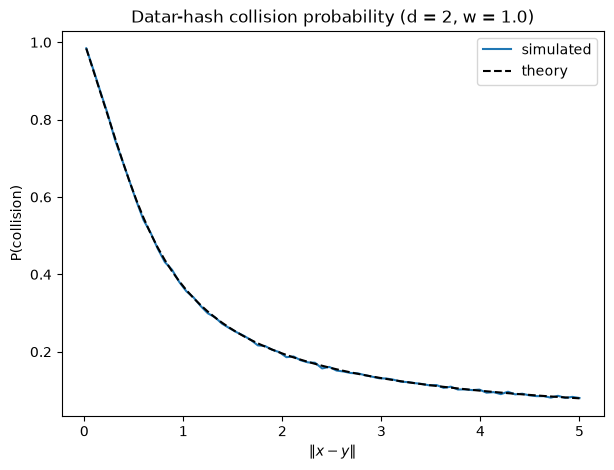

In [16]:
t_values = np.linspace(0.02, 5.0, 70)
d_lsh, w_lsh = 2, 1.0
rng_lsh = np.random.default_rng(11)

probs_base = collision_prob_curve(t_values, d_lsh, w_lsh, rng_lsh)

plt.figure(figsize=(7, 5))
plt.plot(t_values, probs_base, label="simulated")
plt.plot(t_values, collision_prob_theory(t_values, w_lsh), "k--", label="theory")
plt.xlabel(r"$\|x - y\|$")
plt.ylabel("P(collision)")
plt.title(f"Datar-hash collision probability (d = {d_lsh}, w = {w_lsh})")
plt.legend()
plt.show()

**(2) Independence from the exact values of x and y**

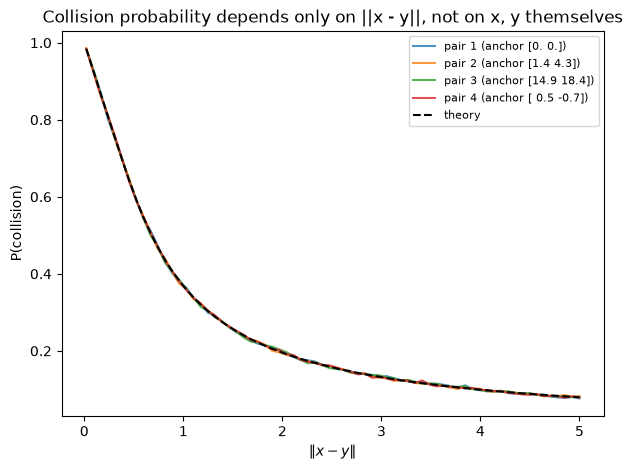

In [17]:
# A handful of unrelated (x, y) pairs: different anchor points, different
# (random) directions, some close to the origin, some far from it.
anchors = [
    np.zeros(d_lsh),
    rng_lsh.normal(size=d_lsh) * 3,
    rng_lsh.normal(size=d_lsh) * 10,
    rng_lsh.normal(size=d_lsh) * 0.5,
]

plt.figure(figsize=(7, 5))
for idx, x0 in enumerate(anchors):
    probs = collision_prob_curve(t_values, d_lsh, w_lsh, rng_lsh, x=x0)
    plt.plot(t_values, probs, alpha=0.8, label=f"pair {idx + 1} (anchor {np.round(x0, 1)})")
plt.plot(t_values, collision_prob_theory(t_values, w_lsh), "k--", label="theory")
plt.xlabel(r"$\|x - y\|$")
plt.ylabel("P(collision)")
plt.title("Collision probability depends only on ||x - y||, not on x, y themselves")
plt.legend(fontsize=8)
plt.show()

**(3) p1, p2 for r = 0.5, c = 4** 

In [18]:
r3, c3 = 0.5, 4
p1, p2 = collision_prob_curve(np.array([r3, c3 * r3]), d_lsh, w_lsh, rng_lsh, n_trials=200_000)

print(f"r = {r3}, c = {c3}  =>  cr = {c3 * r3}")
print(f"p1 = P(collision | dist = r)  = {p1:.4f}")
print(f"p2 = P(collision | dist = cr) = {p2:.4f}")

r = 0.5, c = 4  =>  cr = 2.0
p1 = P(collision | dist = r)  = 0.6109
p2 = P(collision | dist = cr) = 0.1962


**(4) r, c for p1 = 0.8, p2 = 0.1** 

In [19]:
# probs_base is decreasing in t_values; reverse both so np.interp (which
# needs an increasing x-array) can look up t as a function of p.
t_sorted = t_values[::-1]
p_sorted = probs_base[::-1]

r_est = np.interp(0.8, p_sorted, t_sorted)
cr_est = np.interp(0.1, p_sorted, t_sorted)
c_est = cr_est / r_est

print(f"From the simulated curve: r (p=0.8) = {r_est:.4f}, cr (p=0.1) = {cr_est:.4f}, "
      f"c = {c_est:.4f}")

# Cross-check by inverting the closed-form theoretical curve directly.
from scipy.optimize import brentq
r_theory = brentq(lambda t: collision_prob_theory(t, w_lsh) - 0.8, 1e-3, 10)
cr_theory = brentq(lambda t: collision_prob_theory(t, w_lsh) - 0.1, 1e-3, 10)
print(f"From theory:            r (p=0.8) = {r_theory:.4f}, cr (p=0.1) = {cr_theory:.4f}, "
      f"c = {cr_theory / r_theory:.4f}")

From the simulated curve: r (p=0.8) = 0.2525, cr (p=0.1) = 4.0085, c = 15.8730
From theory:            r (p=0.8) = 0.2507, cr (p=0.1) = 3.9684, c = 15.8315


**(5) Effect of w** 

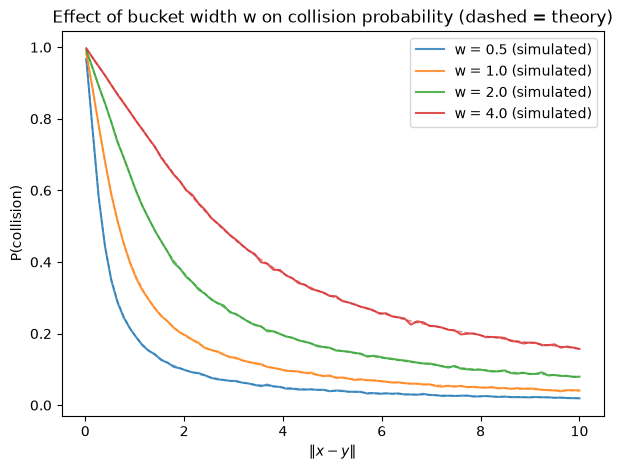

In [20]:
w_values = [0.5, 1.0, 2.0, 4.0]
t_values_w = np.linspace(0.02, 10.0, 80)

plt.figure(figsize=(7, 5))
for w_val in w_values:
    probs_w = collision_prob_curve(t_values_w, d_lsh, w_val, rng_lsh)
    line, = plt.plot(t_values_w, probs_w, alpha=0.8, label=f"w = {w_val} (simulated)")
    plt.plot(t_values_w, collision_prob_theory(t_values_w, w_val), "--",
             color=line.get_color(), linewidth=1, alpha=0.6)
plt.xlabel(r"$\|x - y\|$")
plt.ylabel("P(collision)")
plt.title("Effect of bucket width w on collision probability (dashed = theory)")
plt.legend()
plt.show()

**(6) Effect of d** 

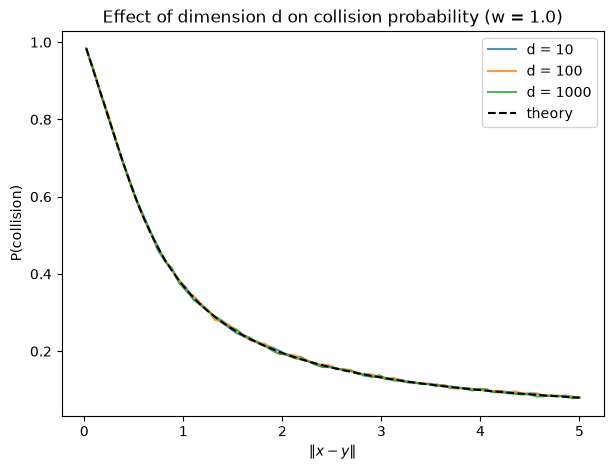

In [21]:
d_values = [10, 100, 1000]

plt.figure(figsize=(7, 5))
for d_val in d_values:
    probs_d = collision_prob_curve(t_values, d_val, w_lsh, rng_lsh)
    plt.plot(t_values, probs_d, alpha=0.8, label=f"d = {d_val}")
plt.plot(t_values, collision_prob_theory(t_values, w_lsh), "k--", label="theory")
plt.xlabel(r"$\|x - y\|$")
plt.ylabel("P(collision)")
plt.title(f"Effect of dimension d on collision probability (w = {w_lsh})")
plt.legend()
plt.show()

### Question 2: LSH on a Toy Dataset

In [22]:
# DATA CELL
# DO NOT EDIT THE CELL
rng = np.random.default_rng(seed=3841)
n = 10_000
d = 4
r = 1
c = 3

X = rng.uniform(-3, 3, size=(n, d))
x_query = rng.uniform(-3, 3, size=(d, ))

**(1) Find neighbours and strangers.** 

In [23]:
dists = np.linalg.norm(X - x_query, axis=1)

is_neighbour = dists <= r          # positive class
is_stranger = dists > c * r        # negative class
is_gray_zone = ~is_neighbour & ~is_stranger

print(f"Neighbours (dist <= r={r}):        {is_neighbour.sum()}")
print(f"Strangers  (dist >  cr={c*r}):       {is_stranger.sum()}")
print(f"Gray zone  (r < dist <= cr):     {is_gray_zone.sum()}")
print(f"Total:                           {n}")

Neighbours (dist <= r=1):        37
Strangers  (dist >  cr=3):       8293
Gray zone  (r < dist <= cr):     1670
Total:                           10000


**(2) Choose w, and read off p1, p2.** 

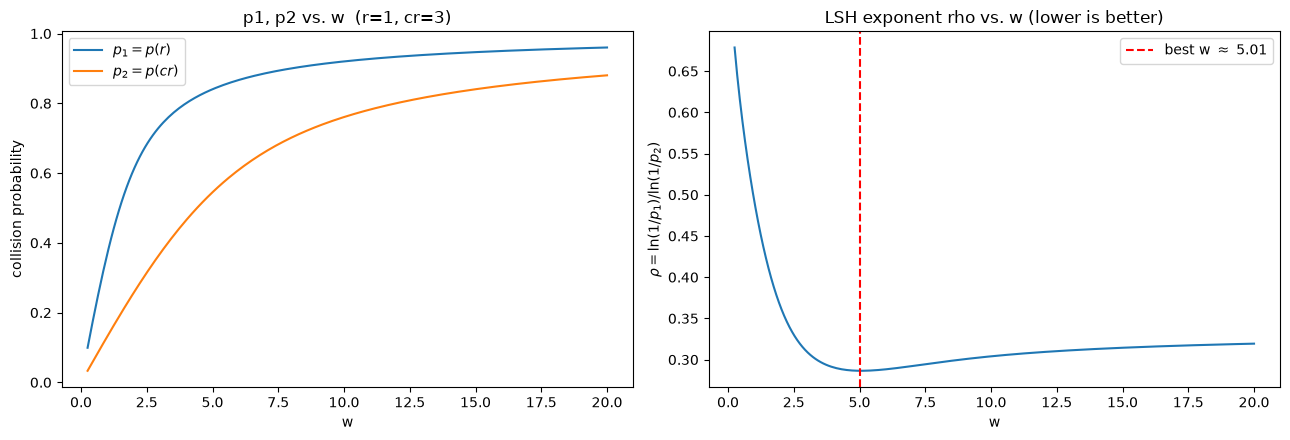

Chosen w = 5.0
p1 = p(r=1)  = 0.8404
p2 = p(cr=3) = 0.5451


In [24]:
w_grid = np.linspace(0.25, 20, 200)
p1_grid = collision_prob_theory(r, w_grid)
p2_grid = collision_prob_theory(c * r, w_grid)
rho_grid = np.log(1 / p1_grid) / np.log(1 / p2_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(w_grid, p1_grid, label=r"$p_1 = p(r)$")
axes[0].plot(w_grid, p2_grid, label=r"$p_2 = p(cr)$")
axes[0].set_xlabel("w")
axes[0].set_ylabel("collision probability")
axes[0].set_title(f"p1, p2 vs. w  (r={r}, cr={c*r})")
axes[0].legend()

axes[1].plot(w_grid, rho_grid)
w_best = w_grid[np.argmin(rho_grid)]
axes[1].axvline(w_best, color="red", linestyle="--", label=f"best w $\\approx$ {w_best:.2f}")
axes[1].set_xlabel("w")
axes[1].set_ylabel(r"$\rho = \ln(1/p_1) / \ln(1/p_2)$")
axes[1].set_title("LSH exponent rho vs. w (lower is better)")
axes[1].legend()

plt.tight_layout()
plt.show()

w_lsh2 = 5.0  # close to the rho-minimizing value found above
p1_lsh2 = collision_prob_theory(r, w_lsh2)
p2_lsh2 = collision_prob_theory(c * r, w_lsh2)
print(f"Chosen w = {w_lsh2}")
print(f"p1 = p(r={r})  = {p1_lsh2:.4f}")
print(f"p2 = p(cr={c*r}) = {p2_lsh2:.4f}")

**(3) Choose theta, and find rho, k, L.**

In [25]:
theta = 0.9  # want a true neighbour to be found w.p. >= 90%

rho = np.log(1 / p1_lsh2) / np.log(1 / p2_lsh2)
k_lsh = int(np.ceil(np.log(n) / np.log(1 / p2_lsh2)))
L_lsh = int(np.ceil(np.log(1 - theta) / np.log(1 - p1_lsh2**k_lsh)))

print(f"theta = {theta}")
print(f"rho = {rho:.4f}")
print(f"k = {k_lsh}")
print(f"L = {L_lsh}")
print(f"Sanity check: p1^k = {p1_lsh2**k_lsh:.4f}, p2^k = {p2_lsh2**k_lsh:.6f}")
print(f"P(neighbour found by >=1 of L tables) = {1 - (1 - p1_lsh2**k_lsh)**L_lsh:.4f}")
print(f"Expected # strangers colliding with query per table = {n * p2_lsh2**k_lsh:.4f}")

theta = 0.9
rho = 0.2865
k = 16
L = 37
Sanity check: p1^k = 0.0619, p2^k = 0.000061
P(neighbour found by >=1 of L tables) = 0.9061
Expected # strangers colliding with query per table = 0.6069


**(4) Build L hash tables of k hash functions, and evaluate.** 

In [26]:
rng_hash = np.random.default_rng(99)

candidate = np.zeros(n, dtype=bool)  # OR across tables
for table in range(L_lsh):
    A = rng_hash.normal(size=(k_lsh, d))       # k hash functions' a-vectors
    B = rng_hash.uniform(0, w_lsh2, size=k_lsh)  # k hash functions' b-offsets

    H_X = np.floor((X @ A.T + B) / w_lsh2)         # (n, k) hash codes for the dataset
    H_q = np.floor((x_query @ A.T + B) / w_lsh2)   # (k,)   hash code for the query

    collides_this_table = np.all(H_X == H_q, axis=1)  # AND across the k hashes
    candidate |= collides_this_table

TP = int(np.sum(candidate & is_neighbour))
FN = int(np.sum(~candidate & is_neighbour))
FP = int(np.sum(candidate & is_stranger))
TN = int(np.sum(~candidate & is_stranger))

precision = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
recall = TP / (TP + FN) if (TP + FN) > 0 else float("nan")

print(f"TP = {TP}, FP = {FP}, TN = {TN}, FN = {FN}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")

TP = 37, FP = 1, TN = 8292, FN = 0
Precision = 0.9737
Recall    = 1.0000


## Randomized SVD

### Question 1: Randomized SVD from Scratch

(400, 300)


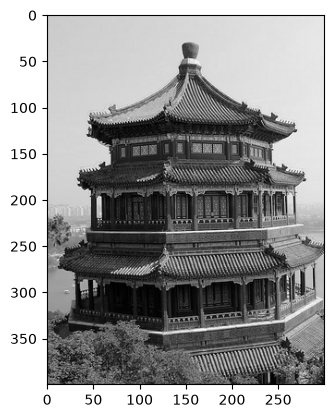

In [27]:
# DATA CELL
# DO NOT EDIT THIS CELL
from sklearn.datasets import load_sample_image

rng = np.random.default_rng(seed=1934)
china_color = load_sample_image("china.jpg")
img = np.dot(china_color[..., :3], [0.2989, 0.5870, 0.1140])
A = img[:400, 50:350]
plt.imshow(A, cmap='gray')
print(A.shape)

**(1) Full SVD and the best rank-25 approximation.** 

rank(B) = 25
||A - B||_2 = 1260.8865
(should equal sigma_26 = S[25] = 1260.8865, by Eckart-Young)


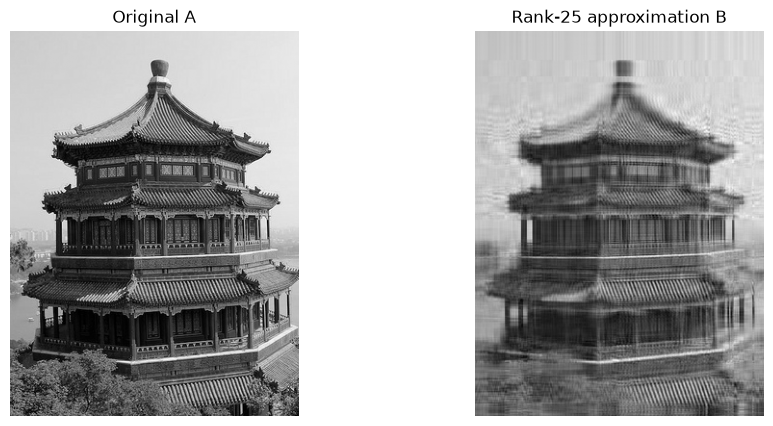

In [28]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)

rank_B = 25
B = (U[:, :rank_B] * S[:rank_B]) @ Vt[:rank_B, :]
norm_B_A = np.linalg.norm(A - B, ord=2)  # spectral (largest singular value) norm

print(f"rank(B) = {rank_B}")
print(f"||A - B||_2 = {norm_B_A:.4f}")
print(f"(should equal sigma_{rank_B + 1} = S[{rank_B}] = {S[rank_B]:.4f}, by Eckart-Young)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(A, cmap="gray")
axes[0].set_title("Original A")
axes[1].imshow(B, cmap="gray")
axes[1].set_title(f"Rank-{rank_B} approximation B")
for ax in axes:
    ax.axis("off")
plt.show()

**(2) Singular values on a log scale, and the elbow.** 

Elbow at index k = 25 (0-indexed), sigma_k = 1260.8865
(i.e. the top 25 singular values are the 'steep' part; S[25] onward is the flat tail)


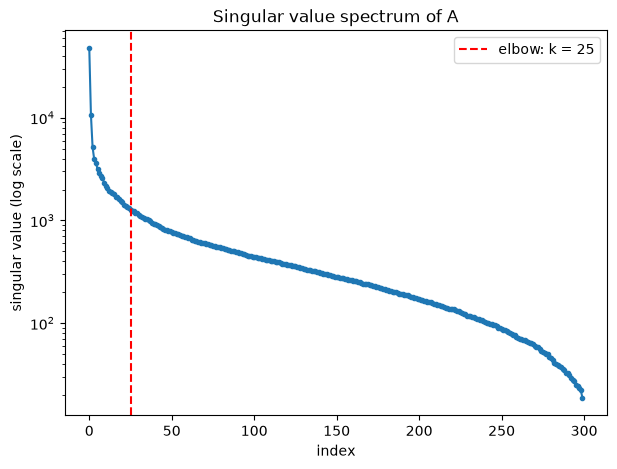

In [29]:
log_S = np.log(S)
idx = np.arange(len(S))

# normalize both axes to [0, 1]
x_n = (idx - idx.min()) / (idx.max() - idx.min())
y_n = (log_S - log_S.min()) / (log_S.max() - log_S.min())

# perpendicular distance of every point from the line joining the endpoints
x0, y0, x1, y1 = x_n[0], y_n[0], x_n[-1], y_n[-1]
dist = np.abs((y1 - y0) * x_n - (x1 - x0) * y_n + x1 * y0 - y1 * x0) / np.sqrt((y1 - y0)**2 + (x1 - x0)**2)

k_elbow = int(np.argmax(dist))   # 0-indexed position where the flat region begins
sigma_k = S[k_elbow]

print(f"Elbow at index k = {k_elbow} (0-indexed), sigma_k = {sigma_k:.4f}")
print(f"(i.e. the top {k_elbow} singular values are the 'steep' part; S[{k_elbow}] onward is the flat tail)")

plt.figure(figsize=(7, 5))
plt.semilogy(S, marker=".")
plt.axvline(k_elbow, color="red", linestyle="--", label=f"elbow: k = {k_elbow}")
plt.xlabel("index")
plt.ylabel("singular value (log scale)")
plt.title("Singular value spectrum of A")
plt.legend()
plt.show()

**(3) Vanilla randomized SVD** 

In [30]:
def randomized_svd_vanilla(A, k, p, rng):
    """Vanilla randomized SVD (no power iteration). Returns the top-k
    (U, S, Vt) factors of a rank-(k+p) approximate SVD of A."""
    m, n = A.shape
    l = k + p
    Omega = rng.normal(size=(n, l))     # random test matrix
    Y = A @ Omega                       # (m, l), samples the range of A
    Q, _ = np.linalg.qr(Y)              # (m, l), orthonormal basis for range(A)

    B_small = Q.T @ A                   # (l, n), A represented in that basis
    Ub, Sb, Vtb = np.linalg.svd(B_small, full_matrices=False)
    U_full = Q @ Ub                     # lift back to the original space

    return U_full[:, :k], Sb[:k], Vtb[:k, :]


rng_svd = np.random.default_rng(7)
p_rsvd = 5

Uk, Sk, Vtk = randomized_svd_vanilla(A, k_elbow, p_rsvd, rng_svd)
A_hat = (Uk * Sk) @ Vtk
norm_Ahat_A = np.linalg.norm(A - A_hat, ord=2)

ratio = norm_Ahat_A / norm_B_A
print(f"k = {k_elbow}, p = {p_rsvd}")
print(f"||A - A_hat||_2 = {norm_Ahat_A:.4f}")
print(f"||B - A||_2     = {norm_B_A:.4f}")
print(f"ratio = {ratio:.4f}")

k = 25, p = 5
||A - A_hat||_2 = 2948.5787
||B - A||_2     = 1260.8865
ratio = 2.3385


**(4) Average over 50 runs, for p in {5, 10, 15, 20, 25}.** 

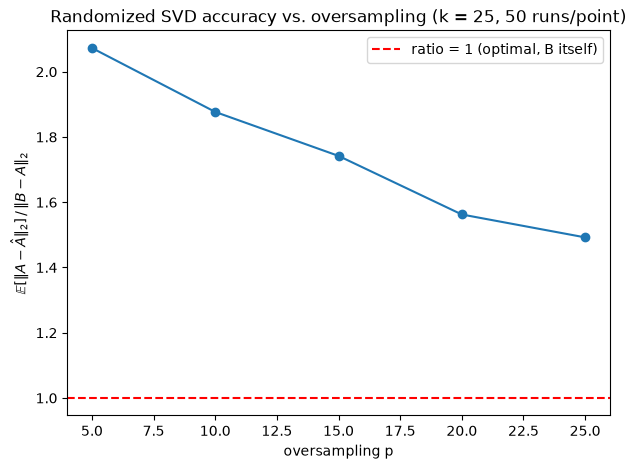

p =  5: mean ratio = 2.0728
p = 10: mean ratio = 1.8768
p = 15: mean ratio = 1.7421
p = 20: mean ratio = 1.5625
p = 25: mean ratio = 1.4923


In [31]:
p_values = [5, 10, 15, 20, 25]
n_repeats = 50

rng_sweep = np.random.default_rng(2025)
mean_ratio = np.empty(len(p_values))

for i, p_val in enumerate(p_values):
    errs = np.empty(n_repeats)
    for run in range(n_repeats):
        Uk, Sk, Vtk = randomized_svd_vanilla(A, k_elbow, p_val, rng_sweep)
        A_hat = (Uk * Sk) @ Vtk
        errs[run] = np.linalg.norm(A - A_hat, ord=2)
    mean_ratio[i] = errs.mean() / norm_B_A

plt.figure(figsize=(7, 5))
plt.plot(p_values, mean_ratio, marker="o")
plt.axhline(1.0, color="red", linestyle="--", label="ratio = 1 (optimal, B itself)")
plt.xlabel("oversampling p")
plt.ylabel(r"$\mathbb{E}[\|A - \hat{A}\|_2] \, / \, \|B - A\|_2$")
plt.title(f"Randomized SVD accuracy vs. oversampling (k = {k_elbow}, {n_repeats} runs/point)")
plt.legend()
plt.show()

for p_val, r_val in zip(p_values, mean_ratio):
    print(f"p = {p_val:2d}: mean ratio = {r_val:.4f}")

### Question 2: Power-iteration



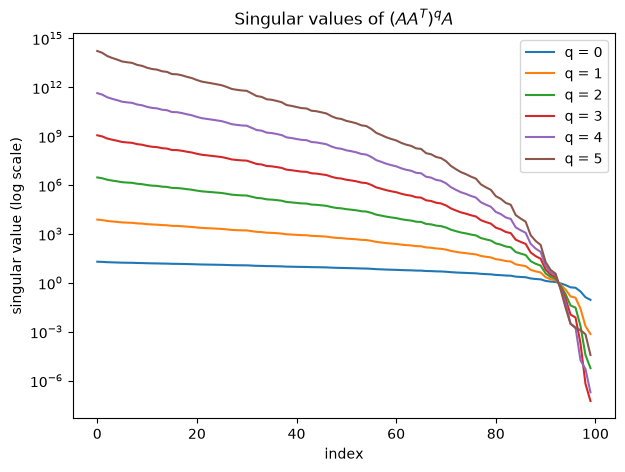

q=1: max abs diff between actual and sigma_i^(2q+1) prediction = 7.276e-12
q=3: max abs diff between actual and sigma_i^(2q+1) prediction = 3.934e-06
q=5: max abs diff between actual and sigma_i^(2q+1) prediction = 8.750e-01


In [32]:
rng_pi = np.random.default_rng(123)
A_pi = rng_pi.normal(size=(100, 100))
AAt_pi = A_pi @ A_pi.T

q_values = [0, 1, 2, 3, 4, 5]
singular_values_q = {}

current = A_pi
for q in q_values:
    if q > 0:
        current = AAt_pi @ current   # multiply by (AA^T) once more each step
    singular_values_q[q] = np.linalg.svd(current, compute_uv=False)

plt.figure(figsize=(7, 5))
for q in q_values:
    plt.semilogy(singular_values_q[q], label=f"q = {q}")
plt.xlabel("index")
plt.ylabel("singular value (log scale)")
plt.title(r"Singular values of $(AA^T)^q A$")
plt.legend()
plt.show()

# sanity check against the closed form: sigma_i(q) = sigma_i(0)^(2q+1)
sigma0 = singular_values_q[0]
for q in [1, 3, 5]:
    predicted = sigma0**(2 * q + 1)
    actual = singular_values_q[q]
    print(f"q={q}: max abs diff between actual and sigma_i^(2q+1) prediction = "
          f"{np.max(np.abs(predicted - actual)):.3e}")

### Question 3: PCA


In [33]:
from sklearn.datasets import fetch_lfw_people
from PIL import Image

# color=False already averages the RGB channels for us (grayscale), and the
# loader returns float32 pixel values already scaled to [0, 1].
lfw = fetch_lfw_people(resize=1.0, color=False, min_faces_per_person=0, slice_=None)
faces_raw = lfw.images  # (n_samples, H, W), float32 in [0, 1]

print(f"Number of images: {faces_raw.shape[0]}")
print(f"Native image size: {faces_raw.shape[1]} x {faces_raw.shape[2]}")
print(f"Pixel range: [{faces_raw.min():.3f}, {faces_raw.max():.3f}]")

Number of images: 13233
Native image size: 250 x 250


Pixel range: [0.000, 1.000]


Resized shape: (13233, 100, 100), pixel range [0.000, 1.000]


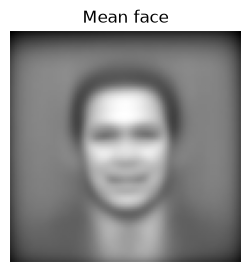

In [34]:
# Resize every image to exactly 100 x 100 (already grayscale, already in [0,1]).
n_faces = faces_raw.shape[0]
faces_100 = np.empty((n_faces, 100, 100), dtype=np.float32)
for i in range(n_faces):
    im = Image.fromarray((faces_raw[i] * 255).astype(np.uint8))
    im = im.resize((100, 100), Image.BILINEAR)
    faces_100[i] = np.asarray(im, dtype=np.float32) / 255.0

print(f"Resized shape: {faces_100.shape}, pixel range [{faces_100.min():.3f}, {faces_100.max():.3f}]")

# Flatten to (n_samples, n_features) and center.
X_faces = faces_100.reshape(n_faces, -1)
mean_face = X_faces.mean(axis=0)
X_faces_centered = X_faces - mean_face

plt.figure(figsize=(3, 3))
plt.imshow(mean_face.reshape(100, 100), cmap="gray")
plt.title("Mean face")
plt.axis("off")
plt.show()

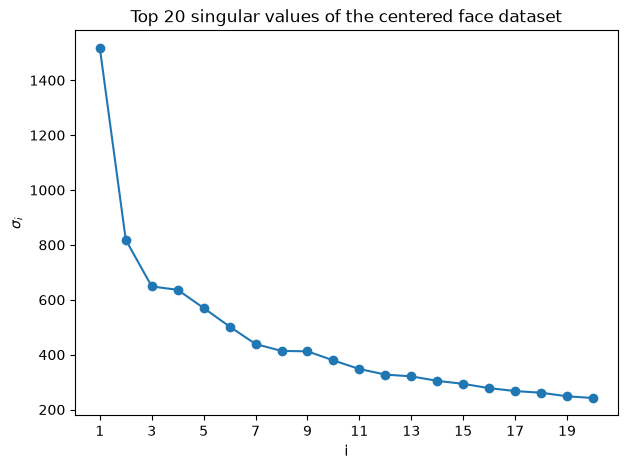

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, svd_solver="randomized", random_state=0)
pca.fit(X_faces_centered)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, 21), pca.singular_values_, marker="o")
plt.xlabel("i")
plt.ylabel(r"$\sigma_i$")
plt.title("Top 20 singular values of the centered face dataset")
plt.xticks(np.arange(1, 21, 2))
plt.show()

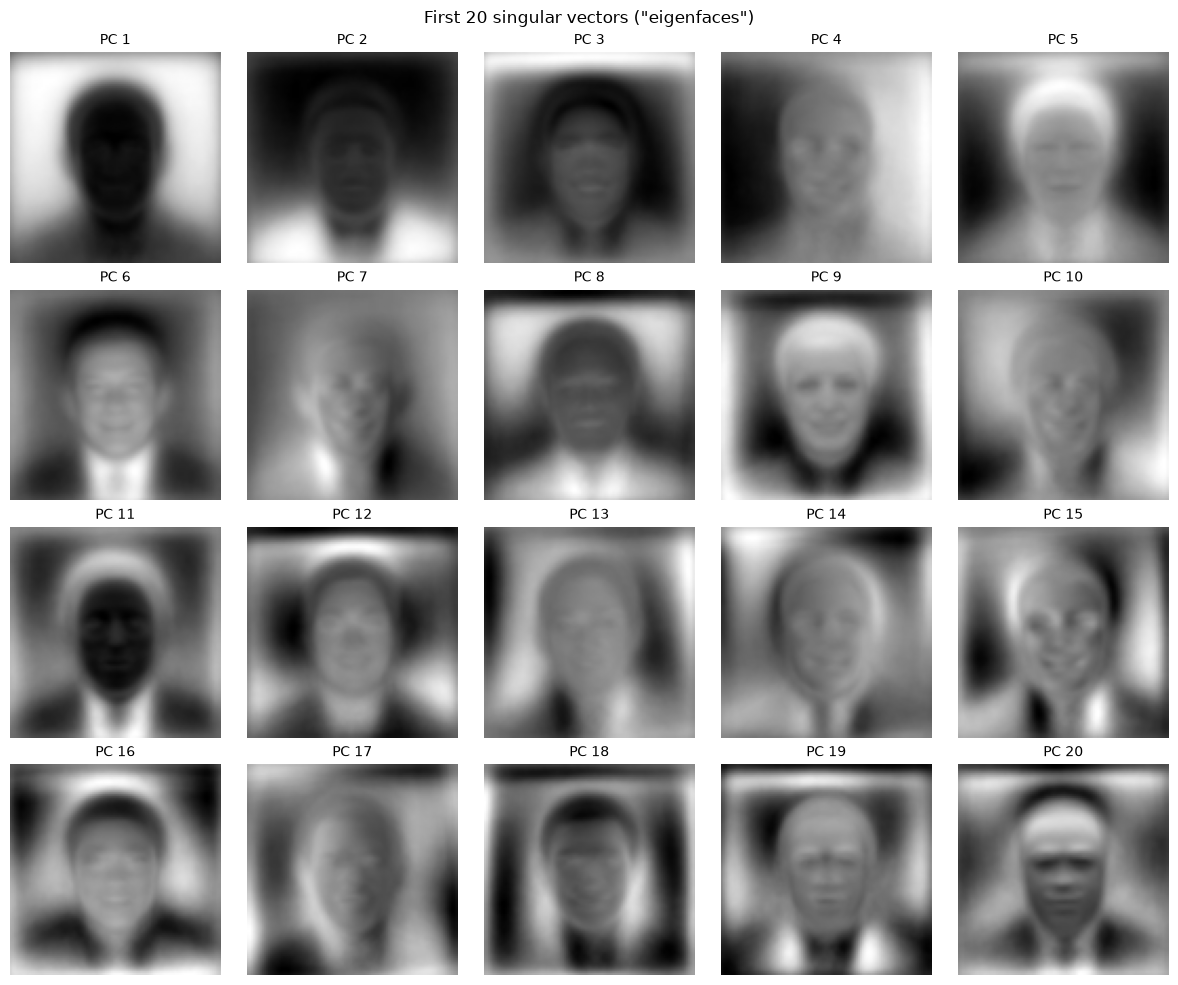

In [36]:
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(100, 100), cmap="gray")
    ax.set_title(f"PC {i + 1}", fontsize=10)
    ax.axis("off")
plt.suptitle("First 20 singular vectors (\"eigenfaces\")")
plt.tight_layout()
plt.show()

## Spectral Clustering

### Question 1: Spectral Clustering using NumPy


In [37]:
# DATA CELL
# DO NOT EDIT THIS CELL
rng = np.random.default_rng(seed=1001)

x1 = rng.multivariate_normal(
    mean=[2, 2, 2], cov=np.eye(3), size=50
)
x2 = rng.multivariate_normal(
    mean=[-3, -3, -3], cov=np.eye(3), size=50
)
x3 = rng.multivariate_normal(
    mean=[-2, -2, 6], cov=np.eye(3), size=50
)
X = np.concatenate(
    [x1, x2, x3], axis=0
)

In [38]:
sigma_sc = 2

D2_sc = pairwise_sq_dists(X.T)               # (150, 150) squared distances
W_sc = np.exp(-D2_sc / (2 * sigma_sc**2))    # weighted graph (Gaussian kernel)

D_sc = np.diag(W_sc.sum(axis=1))             # degree matrix
L_sc = D_sc - W_sc                           # (unnormalized) graph Laplacian

print(f"W shape: {W_sc.shape}, D shape: {D_sc.shape}, L shape: {L_sc.shape}")
print(f"L symmetric: {np.allclose(L_sc, L_sc.T)}")

W shape: (150, 150), D shape: (150, 150), L shape: (150, 150)
L symmetric: True


In [39]:
# L is symmetric, so eigh (for symmetric/Hermitian matrices) is both faster
# and numerically more stable than a general eigensolver, and it conveniently
# returns eigenvalues already sorted in ascending order.
eigvals_sc, eigvecs_sc = np.linalg.eigh(L_sc)

print("Three smallest eigenvalues:", eigvals_sc[:3])

Three smallest eigenvalues: [9.17530101e-15 5.93915504e-02 8.44207638e-01]


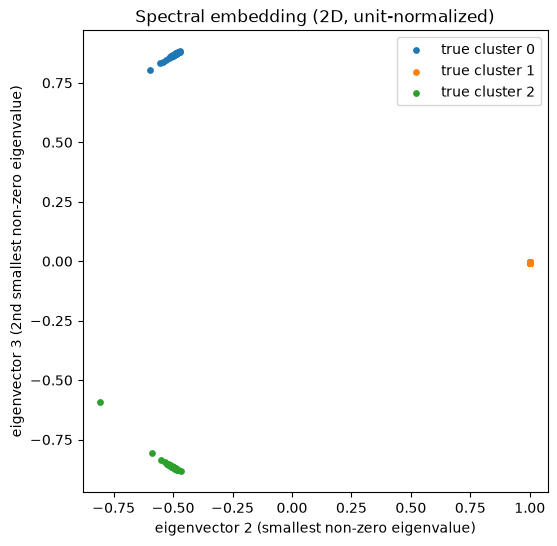

In [40]:
# eigvals_sc[0] is the trivial ~0 eigenvalue (eigenvector = constant vector,
# always present for any graph Laplacian, carries no clustering information).
# The two smallest NON-zero eigenvalues are eigvals_sc[1] and eigvals_sc[2].
embedding = eigvecs_sc[:, [1, 2]]                                   # (150, 2)
embedding_normalized = embedding / np.linalg.norm(embedding, axis=1, keepdims=True)

# Ground-truth cluster labels (from how the data was generated) are only
# used here to color the plot for interpretability -- not used in the
# clustering itself.
true_labels = np.repeat([0, 1, 2], 50)

plt.figure(figsize=(6, 6))
for c in range(3):
    pts = embedding_normalized[true_labels == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=15, label=f"true cluster {c}")
plt.xlabel("eigenvector 2 (smallest non-zero eigenvalue)")
plt.ylabel("eigenvector 3 (2nd smallest non-zero eigenvalue)")
plt.title("Spectral embedding (2D, unit-normalized)")
plt.legend()
plt.axis("equal")
plt.show()

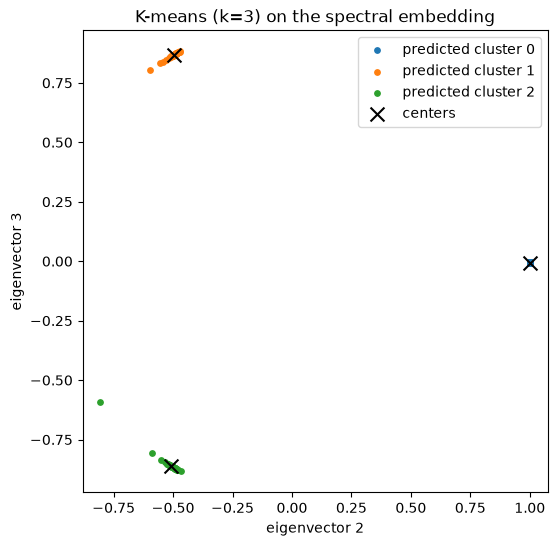

Confusion matrix (rows = predicted cluster, cols = true cluster):
[[ 0 50  0]
 [50  0  0]
 [ 0  0 50]]
Accuracy (best label matching): 1.0000


In [41]:
def kmeans_numpy(X, k, rng, n_init=10, max_iter=300, tol=1e-8):
    """Lloyd's algorithm, NumPy only. Runs n_init random restarts (picking
    k distinct data points as initial centers each time) and keeps the
    lowest-inertia result, same idea as sklearn's n_init to avoid bad local
    optima."""
    best_inertia = np.inf
    best_labels, best_centers = None, None

    for _ in range(n_init):
        centers = X[rng.choice(X.shape[0], size=k, replace=False)].copy()

        for _ in range(max_iter):
            d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(axis=2)  # (n, k)
            labels = np.argmin(d2, axis=1)

            new_centers = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
                for j in range(k)
            ])
            shift = np.linalg.norm(new_centers - centers)
            centers = new_centers
            if shift < tol:
                break

        d2 = ((X[:, None, :] - centers[None, :, :])**2).sum(axis=2)
        labels = np.argmin(d2, axis=1)
        inertia = d2[np.arange(X.shape[0]), labels].sum()

        if inertia < best_inertia:
            best_inertia, best_labels, best_centers = inertia, labels, centers

    return best_labels, best_centers, best_inertia


rng_km = np.random.default_rng(0)
sc_labels, sc_centers, sc_inertia = kmeans_numpy(embedding_normalized, k=3, rng=rng_km)

plt.figure(figsize=(6, 6))
for c in range(3):
    pts = embedding_normalized[sc_labels == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=15, label=f"predicted cluster {c}")
plt.scatter(sc_centers[:, 0], sc_centers[:, 1], c="black", marker="x", s=100, label="centers")
plt.xlabel("eigenvector 2")
plt.ylabel("eigenvector 3")
plt.title("K-means (k=3) on the spectral embedding")
plt.legend()
plt.axis("equal")
plt.show()

# Since k-means cluster indices are arbitrary, match each predicted cluster
# to whichever true cluster is its majority, then report accuracy.
confusion = np.array([[(np.array(sc_labels) == p) & (true_labels == t) for t in range(3)]
                       for p in range(3)]).sum(axis=2)
print("Confusion matrix (rows = predicted cluster, cols = true cluster):")
print(confusion)
best_match_acc = confusion.max(axis=1).sum() / len(true_labels)
print(f"Accuracy (best label matching): {best_match_acc:.4f}")

### Question 2: Spectral Clustering on Toy Datasets

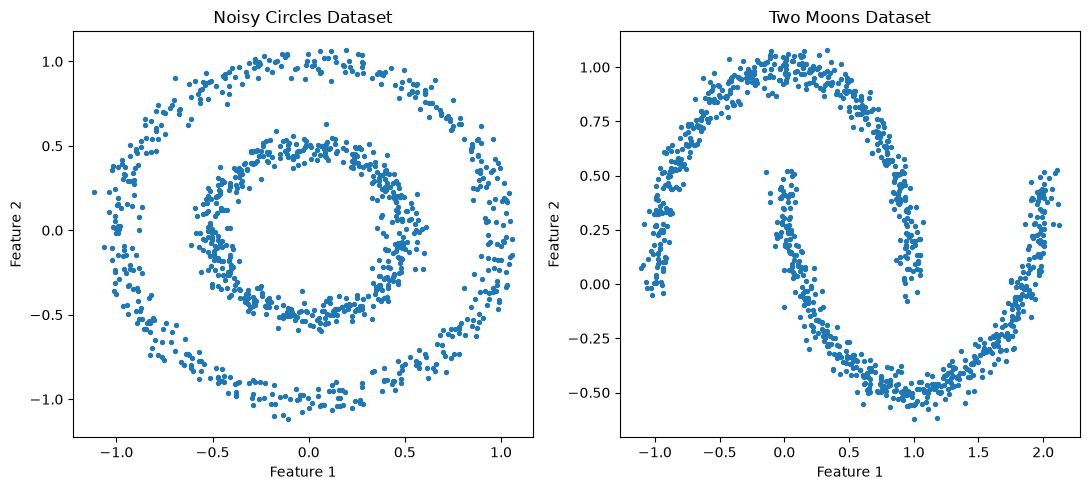

In [42]:
from sklearn.datasets import make_circles, make_moons

X_circles, y_circles = make_circles(n_samples=1000, factor=0.5, noise=0.05, random_state=42)
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(X_circles[:, 0], X_circles[:, 1], s=8)
axes[0].set_title("Noisy Circles Dataset")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], s=8)
axes[1].set_title("Two Moons Dataset")
axes[1].set_xlabel("Feature 1"); axes[1].set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [43]:
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score

datasets_sc2 = {"Noisy Circles": (X_circles, y_circles), "Two Moons": (X_moons, y_moons)}

kmeans_results = {}
for name, (Xd, yd) in datasets_sc2.items():
    km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(Xd)
    kmeans_results[name] = km.labels_
    print(f"{name}: KMeans ARI = {adjusted_rand_score(yd, km.labels_):.4f}")

Noisy Circles: KMeans ARI = -0.0010
Two Moons: KMeans ARI = 0.2393


**Spectral clustering: default parameters first.** 

In [44]:
import warnings

spectral_default_results = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # benign "graph not fully connected" warnings
    for name, (Xd, yd) in datasets_sc2.items():
        sc = SpectralClustering(n_clusters=2, random_state=0).fit(Xd)
        spectral_default_results[name] = sc.labels_
        print(f"{name}: SpectralClustering (default, rbf gamma=1.0) ARI = "
              f"{adjusted_rand_score(yd, sc.labels_):.4f}")

Noisy Circles: SpectralClustering (default, rbf gamma=1.0) ARI = -0.0010
Two Moons: SpectralClustering (default, rbf gamma=1.0) ARI = 0.2952


**Explore the API: tune hyperparameters.** 

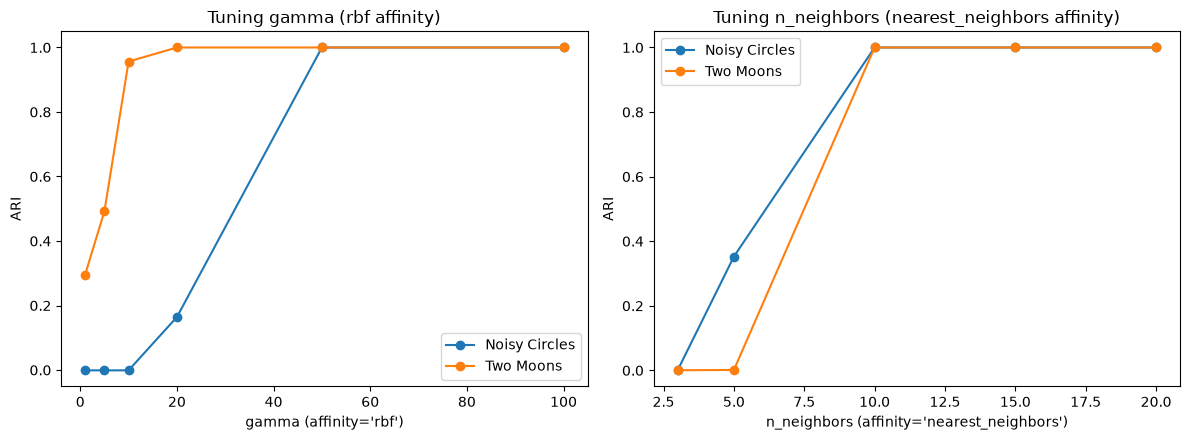

In [45]:
gamma_values = [1, 5, 10, 20, 50, 100]
nn_values = [3, 5, 10, 15, 20]

ari_gamma = {name: [] for name in datasets_sc2}
ari_nn = {name: [] for name in datasets_sc2}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, (Xd, yd) in datasets_sc2.items():
        for g in gamma_values:
            sc = SpectralClustering(n_clusters=2, affinity="rbf", gamma=g, random_state=0).fit(Xd)
            ari_gamma[name].append(adjusted_rand_score(yd, sc.labels_))
        for nn in nn_values:
            sc = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                                     n_neighbors=nn, random_state=0).fit(Xd)
            ari_nn[name].append(adjusted_rand_score(yd, sc.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in datasets_sc2:
    axes[0].plot(gamma_values, ari_gamma[name], marker="o", label=name)
    axes[1].plot(nn_values, ari_nn[name], marker="o", label=name)
axes[0].set_xlabel("gamma (affinity='rbf')"); axes[0].set_ylabel("ARI"); axes[0].legend()
axes[0].set_title("Tuning gamma (rbf affinity)")
axes[1].set_xlabel("n_neighbors (affinity='nearest_neighbors')"); axes[1].set_ylabel("ARI"); axes[1].legend()
axes[1].set_title("Tuning n_neighbors (nearest_neighbors affinity)")
plt.tight_layout()
plt.show()

**Final comparison** with the tuned choice: `affinity='nearest_neighbors'`, `n_neighbors=10` 

Noisy Circles: SpectralClustering (nearest_neighbors, n_neighbors=10) ARI = 1.0000
Two Moons: SpectralClustering (nearest_neighbors, n_neighbors=10) ARI = 1.0000


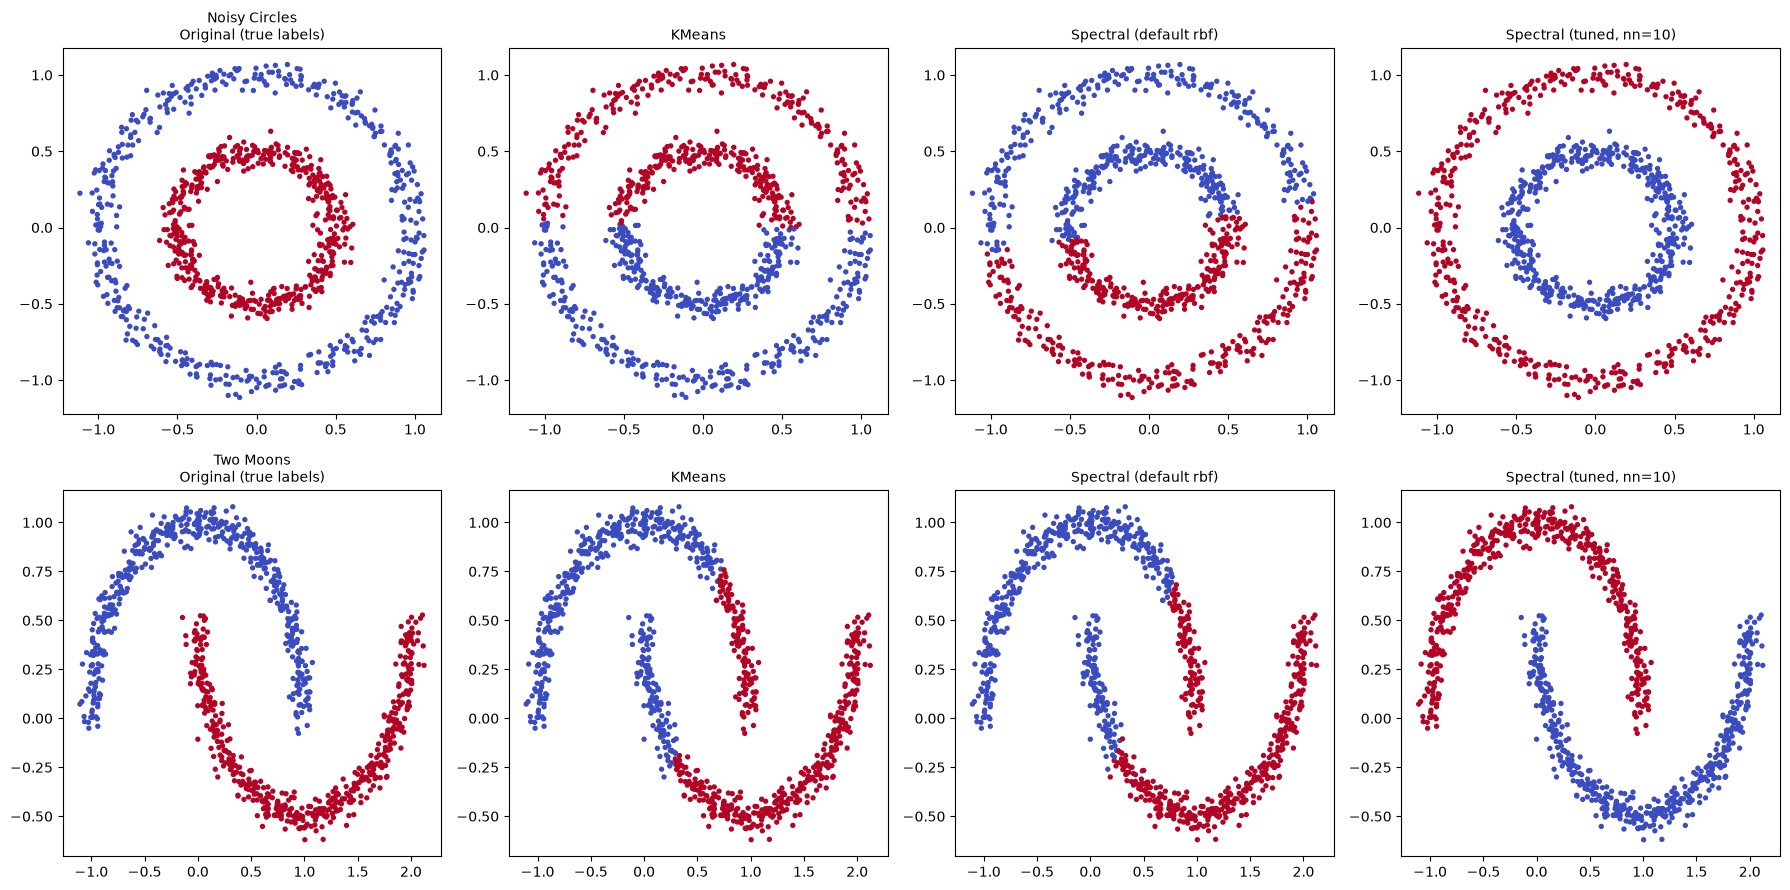

In [46]:
spectral_tuned_results = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, (Xd, yd) in datasets_sc2.items():
        sc = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                                 n_neighbors=10, random_state=0).fit(Xd)
        spectral_tuned_results[name] = sc.labels_
        print(f"{name}: SpectralClustering (nearest_neighbors, n_neighbors=10) ARI = "
              f"{adjusted_rand_score(yd, sc.labels_):.4f}")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for row, (name, (Xd, yd)) in enumerate(datasets_sc2.items()):
    panels = [
        ("Original (true labels)", yd),
        ("KMeans", kmeans_results[name]),
        ("Spectral (default rbf)", spectral_default_results[name]),
        ("Spectral (tuned, nn=10)", spectral_tuned_results[name]),
    ]
    for col, (title, labels) in enumerate(panels):
        ax = axes[row, col]
        ax.scatter(Xd[:, 0], Xd[:, 1], c=labels, cmap="coolwarm", s=8)
        ax.set_title(f"{name}\n{title}" if col == 0 else title, fontsize=10)
plt.tight_layout()
plt.show()

### Question 3: Image Segmentation

Original: (427, 640, 3), downsampled to: (106, 160, 3) (16960 pixels)


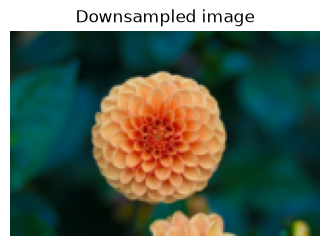

In [47]:
from sklearn.datasets import load_sample_image

flower = load_sample_image("flower.jpg")

scale = 0.25
small = np.asarray(
    Image.fromarray(flower).resize(
        (int(flower.shape[1] * scale), int(flower.shape[0] * scale)), Image.BILINEAR
    )
).astype(np.float64) / 255.0
h, w, _ = small.shape

print(f"Original: {flower.shape}, downsampled to: {small.shape} ({h * w} pixels)")

plt.figure(figsize=(4, 3))
plt.imshow(small)
plt.title("Downsampled image")
plt.axis("off")
plt.show()

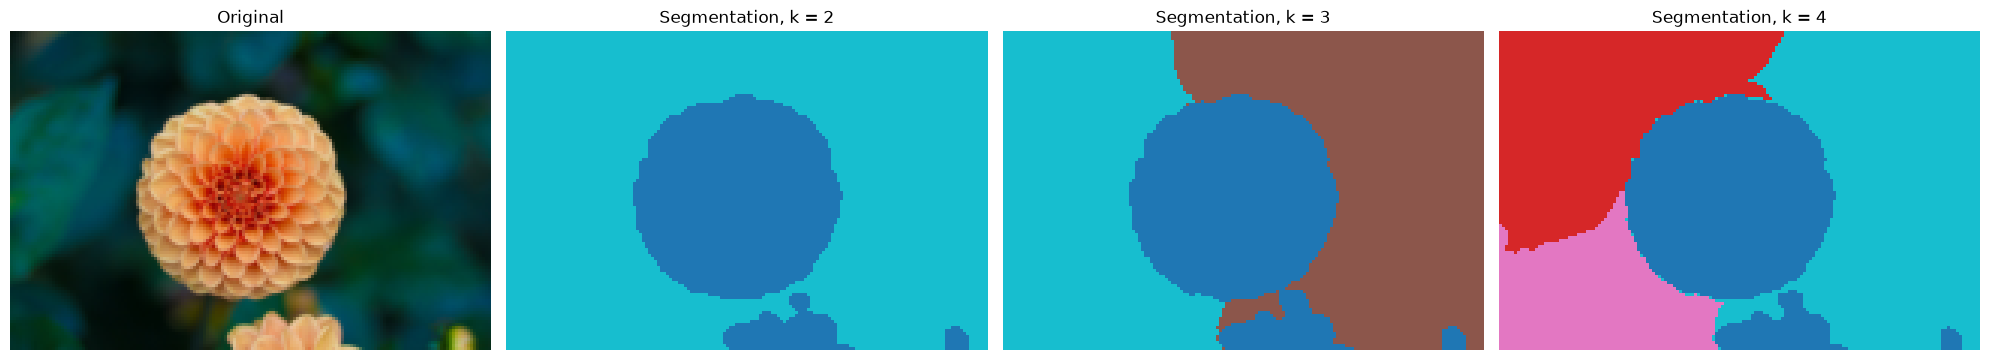

In [48]:
# Each pixel -> a 5D feature vector [R, G, B, x, y]. Spatial coordinates are
# normalized to [0, 1] and down-weighted, so color differences dominate the
# similarity graph but nearby pixels still get a nudge toward the same label
# (encourages spatially contiguous segments rather than scattered speckle).
yy, xx = np.mgrid[0:h, 0:w]
spatial_weight = 0.4
features = np.concatenate([
    small.reshape(-1, 3),
    spatial_weight * (xx / w).reshape(-1, 1),
    spatial_weight * (yy / h).reshape(-1, 1),
], axis=1)

k_values_seg = [2, 3, 4]
segmentations = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for k in k_values_seg:
        sc = SpectralClustering(n_clusters=k, affinity="nearest_neighbors",
                                 n_neighbors=10, random_state=0).fit(features)
        segmentations[k] = sc.labels_.reshape(h, w)

fig, axes = plt.subplots(1, len(k_values_seg) + 1, figsize=(5 * (len(k_values_seg) + 1), 5))
axes[0].imshow(small)
axes[0].set_title("Original")
axes[0].axis("off")
for ax, k in zip(axes[1:], k_values_seg):
    ax.imshow(segmentations[k], cmap="tab10")
    ax.set_title(f"Segmentation, k = {k}")
    ax.axis("off")
plt.tight_layout()
plt.show()